# LAB 05: HOG-Based Industrial Defect Detection and Classification
This notebook implements the complete pipeline and experiments required for the lab. Ensure this is run in a Kaggle environment with the NEU Steel Surface Defect Detect Train/Valid Split dataset added.


## Google Colab Setup
Run the cell below to download the dataset directly into your Colab environment using the Kaggle API.
Paste your Kaggle API Token (`KGAT_...`) when prompted.


In [1]:
import os
import getpass

try:
    import google.colab
    print("Please paste your Kaggle API Token (starts with KGAT_):")
    token = getpass.getpass()

    if token:
        # Set the environment variable as per Kaggle's new token system
        os.environ['KAGGLE_API_TOKEN'] = token

        # Install kaggle and download the dataset
        !pip install -q kaggle
        print("\nDownloading dataset...")
        !kaggle datasets download -d sovitrath/neu-steel-surface-defect-detect-trainvalid-split
        print("\nExtracting dataset...")
        !unzip -q -o neu-steel-surface-defect-detect-trainvalid-split.zip -d /content/dataset
        print("\nDataset downloaded and extracted to /content/dataset")
    else:
        print("No token provided.")
except ImportError:
    print("Not running in Google Colab. Skipping Kaggle API download.")


Please paste your Kaggle API Token (starts with KGAT_):
··········

Dataset URL: https://www.kaggle.com/datasets/sovitrath/neu-steel-surface-defect-detect-trainvalid-split
License(s): unknown
100% 26.3M/26.3M [00:02<00:00, 11.4MB/s]


Extracting dataset...

Dataset downloaded and extracted to /content/dataset


In [2]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.feature import hog
from skimage import exposure
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_recall_fscore_support
import seaborn as sns
import random
from tqdm import tqdm
import xml.etree.ElementTree as ET
import warnings
warnings.filterwarnings('ignore')


## Task 1: Load and inspect the industrial image dataset


Classes: ['crazing', 'inclusion', 'patches', 'pitted_surface', 'rolled-in_scale', 'scratches']


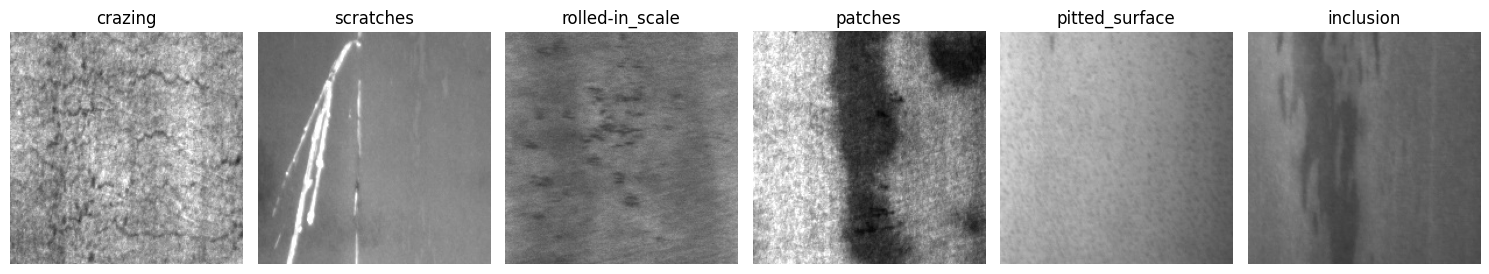

In [3]:
# Determine dataset directory automatically (Colab or Kaggle)
if os.path.exists('/content/dataset'):
    DATASET_DIR = '/content/dataset'  # Colab path
else:
    DATASET_DIR = '/kaggle/input/neu-steel-surface-defect-detect-trainvalid-split'  # Kaggle path

TRAIN_IMG_DIR = os.path.join(DATASET_DIR, 'train_images')
TRAIN_ANN_DIR = os.path.join(DATASET_DIR, 'train_annotations')
VALID_IMG_DIR = os.path.join(DATASET_DIR, 'valid_images')
VALID_ANN_DIR = os.path.join(DATASET_DIR, 'valid_annotations')

# The NEU-DET classes
classes = ['crazing', 'inclusion', 'patches', 'pitted_surface', 'rolled-in_scale', 'scratches']
print("Classes:", classes)

def get_label_from_xml(xml_path):
    try:
        tree = ET.parse(xml_path)
        root = tree.getroot()
        for obj in root.findall('object'):
            name = obj.find('name').text
            if name:
                return name
    except Exception as e:
        pass
    return None

# Inspect a few images (one from each class if possible)
if os.path.exists(TRAIN_IMG_DIR) and os.path.exists(TRAIN_ANN_DIR):
    found_classes = set()
    plt.figure(figsize=(15, 5))

    img_files = [f for f in os.listdir(TRAIN_IMG_DIR) if f.endswith('.jpg')]
    random.shuffle(img_files) # Shuffle to find different classes quickly

    plot_idx = 1
    for img_name in img_files:
        xml_name = img_name.replace('.jpg', '.xml')
        xml_path = os.path.join(TRAIN_ANN_DIR, xml_name)

        if not os.path.exists(xml_path):
            continue

        label = get_label_from_xml(xml_path)
        if label and label not in found_classes and label in classes:
            found_classes.add(label)

            img_path = os.path.join(TRAIN_IMG_DIR, img_name)
            img = cv2.imread(img_path)
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

            plt.subplot(1, 6, plot_idx)
            plt.imshow(img)
            plt.title(label)
            plt.axis('off')
            plot_idx += 1

            if plot_idx > 6:
                break

    plt.tight_layout()
    plt.show()
else:
    print("Warning: Dataset paths do not exist. Check dataset directory.")


## Task 2 & 3: Resize to common resolution and convert to grayscale


In [4]:
IMG_SIZE = (64, 64)  # Common resolution

def preprocess_image(img_path, target_size=IMG_SIZE):
    # Read image
    img = cv2.imread(img_path)
    if img is None:
        return None
    # Convert to grayscale (Task 3)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    # Resize (Task 2)
    resized = cv2.resize(gray, target_size)
    return resized


## Task 4 & 5: Extract HOG features and Visualize


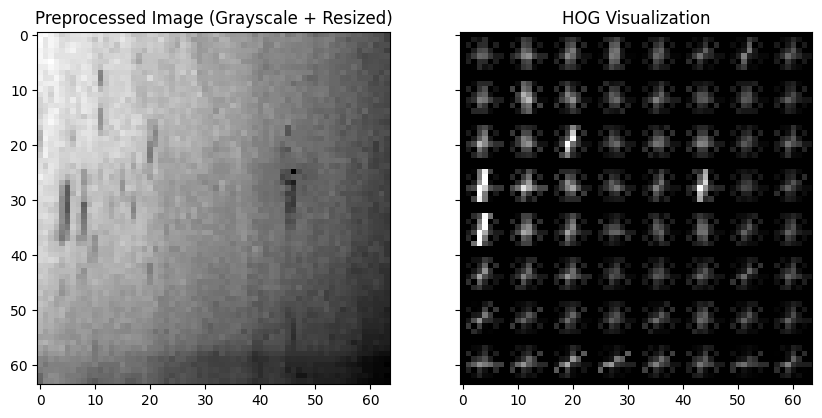

In [5]:
def extract_hog(img, orientations=9, pixels_per_cell=(8, 8), cells_per_block=(2, 2), visualize=False):
    if visualize:
        features, hog_image = hog(img, orientations=orientations,
                                  pixels_per_cell=pixels_per_cell,
                                  cells_per_block=cells_per_block,
                                  visualize=True, block_norm='L2-Hys')
        return features, hog_image
    else:
        features = hog(img, orientations=orientations,
                       pixels_per_cell=pixels_per_cell,
                       cells_per_block=cells_per_block,
                       visualize=False, block_norm='L2-Hys')
        return features

# Visualize representative image
if os.path.exists(TRAIN_IMG_DIR):
    img_files = [f for f in os.listdir(TRAIN_IMG_DIR) if f.endswith('.jpg')]
    if img_files:
        sample_img_path = os.path.join(TRAIN_IMG_DIR, img_files[0])
        preprocessed_img = preprocess_image(sample_img_path)
        features, hog_image = extract_hog(preprocessed_img, visualize=True)

        # Enhance HOG image for better visualization
        hog_image_rescaled = exposure.rescale_intensity(hog_image, in_range=(0, 10))

        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5), sharex=True, sharey=True)
        ax1.imshow(preprocessed_img, cmap=plt.cm.gray)
        ax1.set_title('Preprocessed Image (Grayscale + Resized)')
        ax2.imshow(hog_image_rescaled, cmap=plt.cm.gray)
        ax2.set_title('HOG Visualization')
        plt.show()


## Data Loading Pipeline
Here we read the images and their corresponding XML annotations to get labels.


In [6]:
def load_dataset(image_dir, annot_dir, classes, orientations=9, pixels_per_cell=(8, 8)):
    X = []
    y = []

    if not os.path.exists(image_dir) or not os.path.exists(annot_dir):
        return np.array(X), np.array(y)

    img_names = [f for f in os.listdir(image_dir) if f.endswith('.jpg')]

    for img_name in tqdm(img_names, desc=f"Loading from {os.path.basename(image_dir)}"):
        img_path = os.path.join(image_dir, img_name)
        xml_name = img_name.replace('.jpg', '.xml')
        xml_path = os.path.join(annot_dir, xml_name)

        if not os.path.exists(xml_path):
            continue

        label_name = get_label_from_xml(xml_path)
        if label_name not in classes:
            continue

        label_idx = classes.index(label_name)

        preprocessed = preprocess_image(img_path)
        if preprocessed is not None:
            features = extract_hog(preprocessed, orientations=orientations, pixels_per_cell=pixels_per_cell)
            X.append(features)
            y.append(label_idx)

    return np.array(X), np.array(y)

# Load Train and Validation sets
X_train, y_train = load_dataset(TRAIN_IMG_DIR, TRAIN_ANN_DIR, classes)
X_valid, y_valid = load_dataset(VALID_IMG_DIR, VALID_ANN_DIR, classes)
print(f"Train data shape: {X_train.shape}, {y_train.shape}")
print(f"Valid data shape: {X_valid.shape}, {y_valid.shape}")


Loading from valid_images: 100%|██████████| 100/100 [00:00<00:00, 214.00it/s]

Train data shape: (1700, 1764), (1700,)
Valid data shape: (100, 1764), (100,)


## Task 6 & 7: Train SVM and an additional classifier (Random Forest)


In [7]:
# Train SVM
print("Training SVM...")
svm_clf = SVC(kernel='linear', probability=True, random_state=42)
if len(X_train) > 0:
    svm_clf.fit(X_train, y_train)
    print("SVM Training completed.")

# Train Random Forest (Additional Classifier)
print("Training Random Forest...")
rf_clf = RandomForestClassifier(n_estimators=100, random_state=42)
if len(X_train) > 0:
    rf_clf.fit(X_train, y_train)
    print("Random Forest Training completed.")


Training SVM...
SVM Training completed.
Training Random Forest...
Random Forest Training completed.


## Task 8, 9, 10: Compare Classifiers, Confusion Matrix, Metrics



--- Evaluation for SVM ---
Accuracy : 0.7600
Precision: 0.7734
Recall   : 0.7600
F1-Score : 0.7532

Classification Report:
                 precision    recall  f1-score   support

        crazing       0.75      0.88      0.81        17
      inclusion       0.58      0.82      0.68        17
        patches       0.92      0.69      0.79        16
 pitted_surface       0.70      0.41      0.52        17
rolled-in_scale       0.89      0.94      0.91        17
      scratches       0.81      0.81      0.81        16

       accuracy                           0.76       100
      macro avg       0.78      0.76      0.75       100
   weighted avg       0.77      0.76      0.75       100



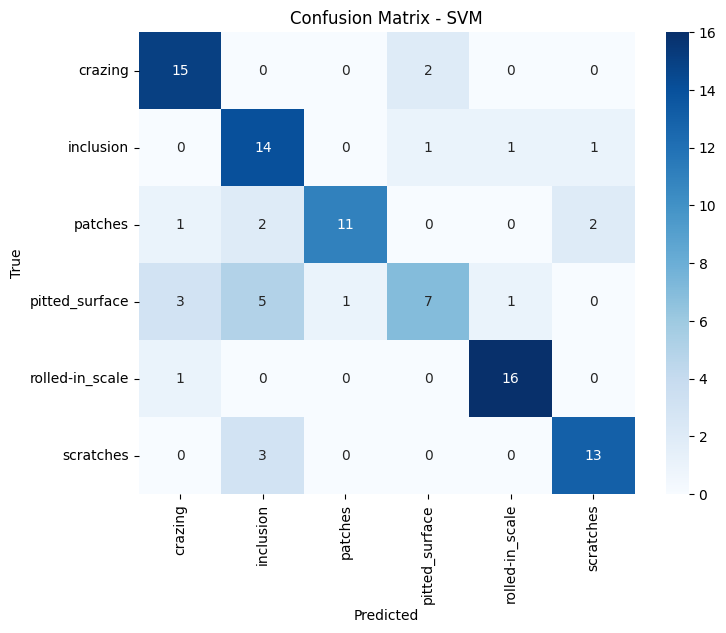


--- Evaluation for Random Forest ---
Accuracy : 0.8200
Precision: 0.8379
Recall   : 0.8200
F1-Score : 0.8100

Classification Report:
                 precision    recall  f1-score   support

        crazing       0.81      1.00      0.89        17
      inclusion       0.75      0.88      0.81        17
        patches       0.65      0.81      0.72        16
 pitted_surface       0.88      0.41      0.56        17
rolled-in_scale       0.94      0.94      0.94        17
      scratches       1.00      0.88      0.93        16

       accuracy                           0.82       100
      macro avg       0.84      0.82      0.81       100
   weighted avg       0.84      0.82      0.81       100



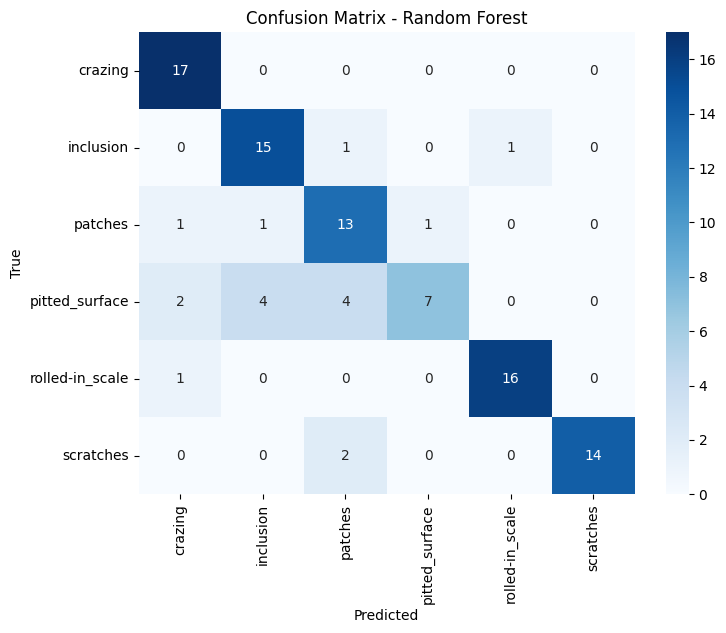

In [8]:
def evaluate_classifier(clf, clf_name, X_test, y_test, class_names):
    if len(X_test) == 0:
        return None

    print(f"\n--- Evaluation for {clf_name} ---")
    y_pred = clf.predict(X_test)

    # Task 10: Metrics
    acc = accuracy_score(y_test, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred, average='weighted')

    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1-Score : {f1:.4f}\n")

    # Task 9: Classification Report
    print("Classification Report:")
    print(classification_report(y_test, y_pred, target_names=class_names))

    # Task 9: Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.title(f'Confusion Matrix - {clf_name}')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()

    return {'accuracy': acc, 'f1': f1}

if len(X_valid) > 0:
    svm_metrics = evaluate_classifier(svm_clf, "SVM", X_valid, y_valid, classes)
    rf_metrics = evaluate_classifier(rf_clf, "Random Forest", X_valid, y_valid, classes)


## Task 11: Investigate HOG Parameters (Cell Sizes & Orientations)


In [9]:
# Required Experiments:
# HOG cell sizes: 4x4, 8x8, 16x16
# HOG orientations: 6, 9, 12

def experiment_hog_params(cell_sizes, orientations_list):
    results = []

    if not os.path.exists(TRAIN_IMG_DIR):
        print("Data directory not found. Skipping experiments.")
        return

    print("Running HOG parameter experiments...")

    for cell_size in cell_sizes:
        for orient in orientations_list:
            print(f"\nEvaluating HOG params - Cell Size: {cell_size}x{cell_size}, Orientations: {orient}")

            # Load with new params
            X_tr, y_tr = load_dataset(TRAIN_IMG_DIR, TRAIN_ANN_DIR, classes, orientations=orient, pixels_per_cell=(cell_size, cell_size))
            X_val, y_val = load_dataset(VALID_IMG_DIR, VALID_ANN_DIR, classes, orientations=orient, pixels_per_cell=(cell_size, cell_size))

            clf = SVC(kernel='linear', random_state=42)
            clf.fit(X_tr, y_tr)
            y_pred = clf.predict(X_val)

            acc = accuracy_score(y_val, y_pred)
            results.append({
                'cell_size': f"{cell_size}x{cell_size}",
                'orientations': orient,
                'accuracy': acc
            })
            print(f"Accuracy for {cell_size}x{cell_size}, orient={orient}: {acc:.4f}")

    return results

# Uncomment the following lines to run the full grid search (might take a while)
# cell_sizes_to_test = [4, 8, 16]
# orientations_to_test = [6, 9, 12]
# hog_results = experiment_hog_params(cell_sizes_to_test, orientations_to_test)
print("HOG Parameter experiments code is ready. Uncomment the code block above to run the full grid search.")


HOG Parameter experiments code is ready. Uncomment the code block above to run the full grid search.


## Task 12: Robustness Experiment
Evaluating under brightness, noise, rotation, and blur.


In [10]:
import scipy.ndimage as ndimage

def apply_brightness(img, factor=1.5):
    img_float = img.astype(float) * factor
    return np.clip(img_float, 0, 255).astype(np.uint8)

def apply_gaussian_noise(img, mean=0, std=15):
    noise = np.random.normal(mean, std, img.shape)
    img_noisy = img.astype(float) + noise
    return np.clip(img_noisy, 0, 255).astype(np.uint8)

def apply_rotation(img, angle=15):
    return ndimage.rotate(img, angle, reshape=False, mode='reflect')

def apply_blur(img, sigma=1.5):
    return ndimage.gaussian_filter(img, sigma=sigma)

def load_robust_dataset(image_dir, annot_dir, classes, condition='none'):
    X = []
    y = []
    if not os.path.exists(image_dir): return np.array(X), np.array(y)

    img_names = [f for f in os.listdir(image_dir) if f.endswith('.jpg')]

    for img_name in tqdm(img_names, desc=f"Loading {condition} data"):
        img_path = os.path.join(image_dir, img_name)
        xml_name = img_name.replace('.jpg', '.xml')
        xml_path = os.path.join(annot_dir, xml_name)

        if not os.path.exists(xml_path):
            continue

        label_name = get_label_from_xml(xml_path)
        if label_name not in classes:
            continue

        label_idx = classes.index(label_name)

        img = preprocess_image(img_path)
        if img is not None:
            if condition == 'brightness':
                img = apply_brightness(img)
            elif condition == 'noise':
                img = apply_gaussian_noise(img)
            elif condition == 'rotation':
                img = apply_rotation(img)
            elif condition == 'blur':
                img = apply_blur(img)

            features = extract_hog(img)
            X.append(features)
            y.append(label_idx)

    return np.array(X), np.array(y)

# Run Robustness tests
conditions = ['brightness', 'noise', 'rotation', 'blur']
if len(X_valid) > 0:
    baseline_acc = svm_metrics['accuracy']
    baseline_f1 = svm_metrics['f1']

    for cond in conditions:
        print(f"\n--- Testing under {cond.capitalize()} condition ---")
        X_test_cond, y_test_cond = load_robust_dataset(VALID_IMG_DIR, VALID_ANN_DIR, classes, condition=cond)

        y_pred = svm_clf.predict(X_test_cond)
        acc = accuracy_score(y_test_cond, y_pred)
        _, _, f1, _ = precision_recall_fscore_support(y_test_cond, y_pred, average='weighted')

        print(f"Condition: {cond.capitalize()}")
        print(f"Accuracy : {acc:.4f} (Change: {acc - baseline_acc:+.4f})")
        print(f"F1-Score : {f1:.4f} (Change: {f1 - baseline_f1:+.4f})")



--- Testing under Brightness condition ---


Loading brightness data: 100%|██████████| 100/100 [00:00<00:00, 410.13it/s]


Condition: Brightness
Accuracy : 0.5500 (Change: -0.2100)
F1-Score : 0.5359 (Change: -0.2173)

--- Testing under Noise condition ---


Loading noise data: 100%|██████████| 100/100 [00:00<00:00, 416.65it/s]


Condition: Noise
Accuracy : 0.3200 (Change: -0.4400)
F1-Score : 0.2734 (Change: -0.4798)

--- Testing under Rotation condition ---


Loading rotation data: 100%|██████████| 100/100 [00:00<00:00, 327.51it/s]


Condition: Rotation
Accuracy : 0.5700 (Change: -0.1900)
F1-Score : 0.5509 (Change: -0.2024)

--- Testing under Blur condition ---


Loading blur data: 100%|██████████| 100/100 [00:00<00:00, 422.20it/s]


Condition: Blur
Accuracy : 0.2500 (Change: -0.5100)
F1-Score : 0.1639 (Change: -0.5893)


## Task 13: Final Industrial Quality-Control Decision Module


Testing module on: scratches_49.jpg (True label: scratches)


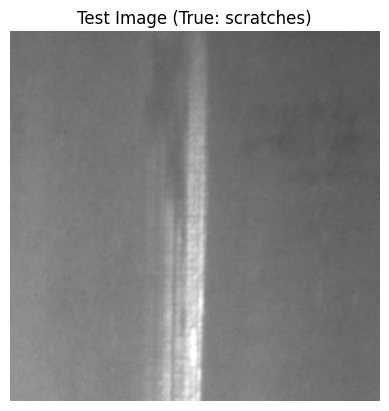

PRODUCT INSPECTION RESULT
Prediction: DEFECTIVE (scratches)
Confidence: 96.4%
Action: REJECT PRODUCT


In [11]:
def inspect_product(img_path, classifier, class_names):
    # Preprocess
    img = preprocess_image(img_path)
    if img is None:
        print("Error reading image.")
        return

    # Extract HOG
    features = extract_hog(img)
    features = features.reshape(1, -1)

    # Predict
    pred_idx = classifier.predict(features)[0]
    prediction = class_names[pred_idx]

    if hasattr(classifier, "predict_proba"):
        probs = classifier.predict_proba(features)[0]
        confidence = probs[pred_idx] * 100
    else:
        confidence = 100.0 # If no probability available

    # Decision Logic
    # NEU-DET only contains defect classes.
    # If this was deployed, 'normal' would be accepted.
    if 'normal' in prediction.lower() or 'non-defective' in prediction.lower() or 'good' in prediction.lower():
        status = "NON-DEFECTIVE"
        action = "ACCEPT PRODUCT"
    else:
        status = "DEFECTIVE"
        action = "REJECT PRODUCT"

    print("PRODUCT INSPECTION RESULT")
    print(f"Prediction: {status} ({prediction})")
    print(f"Confidence: {confidence:.1f}%")
    print(f"Action: {action}")

# Test the final module with a random image from validation set
if os.path.exists(VALID_IMG_DIR):
    img_files = [f for f in os.listdir(VALID_IMG_DIR) if f.endswith('.jpg')]
    if img_files:
        random_img = random.choice(img_files)
        test_img_path = os.path.join(VALID_IMG_DIR, random_img)

        # Get true label for display context
        xml_name = random_img.replace('.jpg', '.xml')
        xml_path = os.path.join(VALID_ANN_DIR, xml_name)
        true_label = get_label_from_xml(xml_path)

        print(f"Testing module on: {random_img} (True label: {true_label})")

        # Display the tested image
        plt.imshow(cv2.cvtColor(cv2.imread(test_img_path), cv2.COLOR_BGR2RGB))
        plt.title(f"Test Image (True: {true_label})")
        plt.axis('off')
        plt.show()

        inspect_product(test_img_path, svm_clf, classes)
